TypeError: Image data of dtype object cannot be converted to float

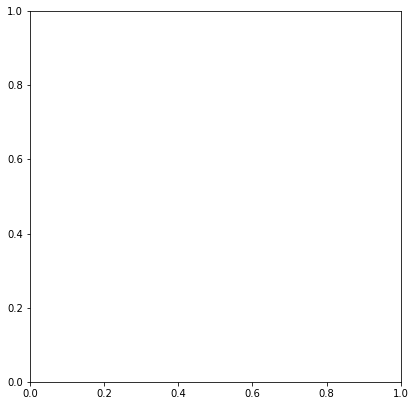

In [2]:
import numpy as np
import cv2
from matplotlib import pyplot as plt



smarties=cv2.imread("smarties.png",cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(15,15))
plt.subplot(211)
plt.imshow(smarties,'gray')

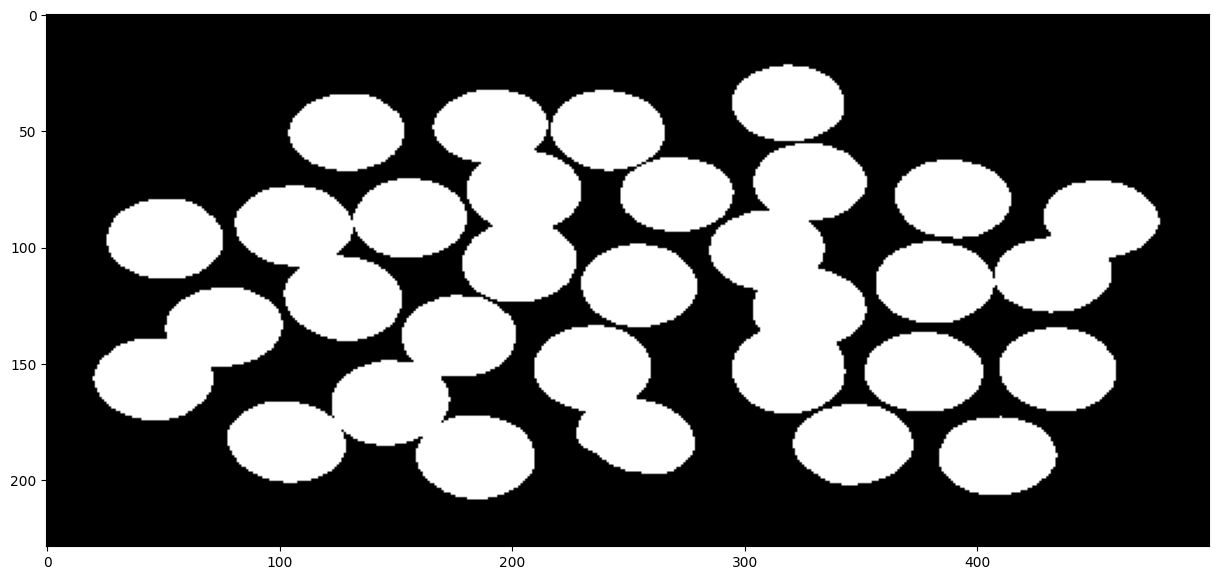

In [ ]:

[ret,thresh]= cv2.threshold(smarties, 245, 1, cv2.THRESH_BINARY_INV)
plt.figure(figsize=(15,15))
plt.imshow(thresh,'gray')

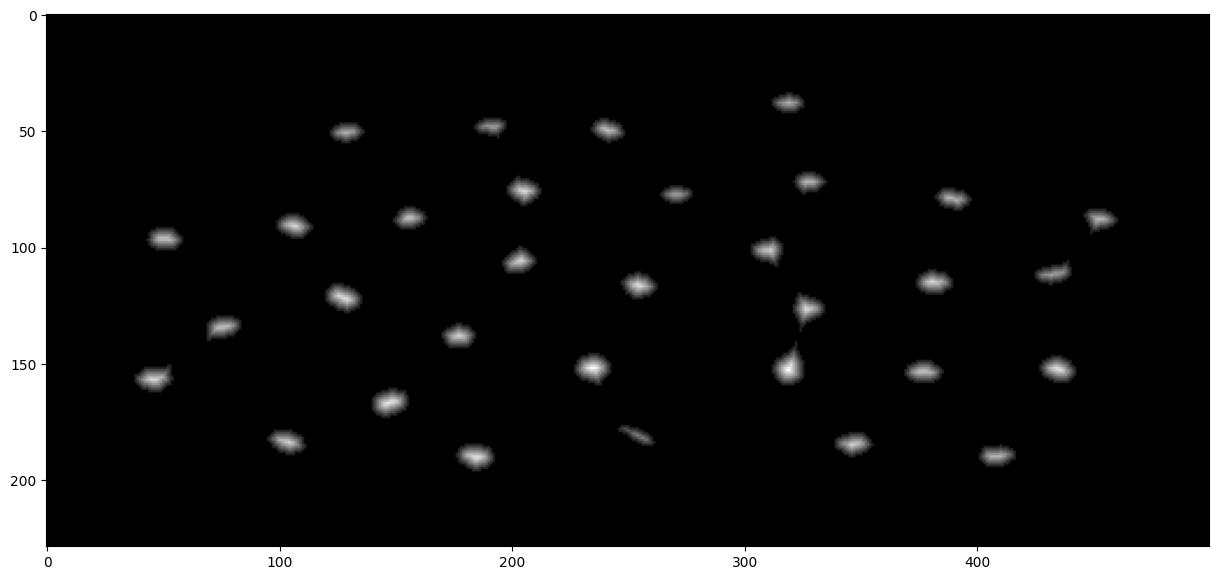

In [ ]:
S = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(35,25))
dist=cv2.distanceTransform(thresh,cv2.DIST_L2,3)

distb=abs(255-255*dist/np.max(dist))


smartieserode=cv2.erode(dist, S, iterations = 1)

plt.figure(figsize=(15,15))
plt.imshow(smartieserode,'gray')

Il y a 34smarties


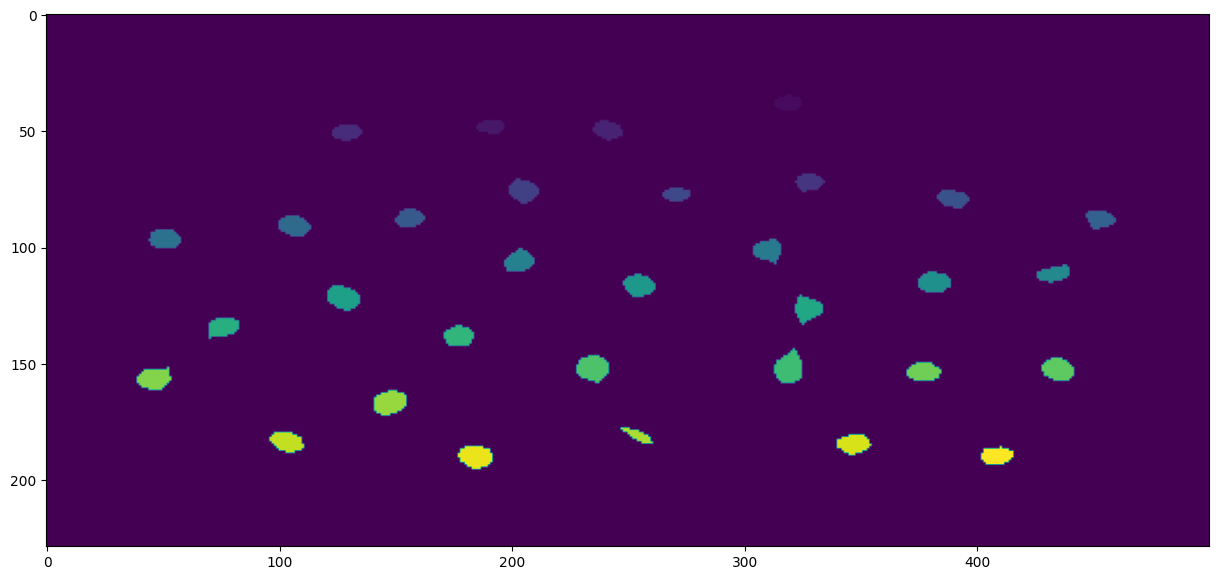

In [ ]:
[num_labels, labels]=cv2.connectedComponents(smartieserode.astype(np.uint8))
print("Il y a "  + str (num_labels+1) + "smarties")

plt.figure(figsize=(15,15))
#Carte des distances
plt.imshow(labels)



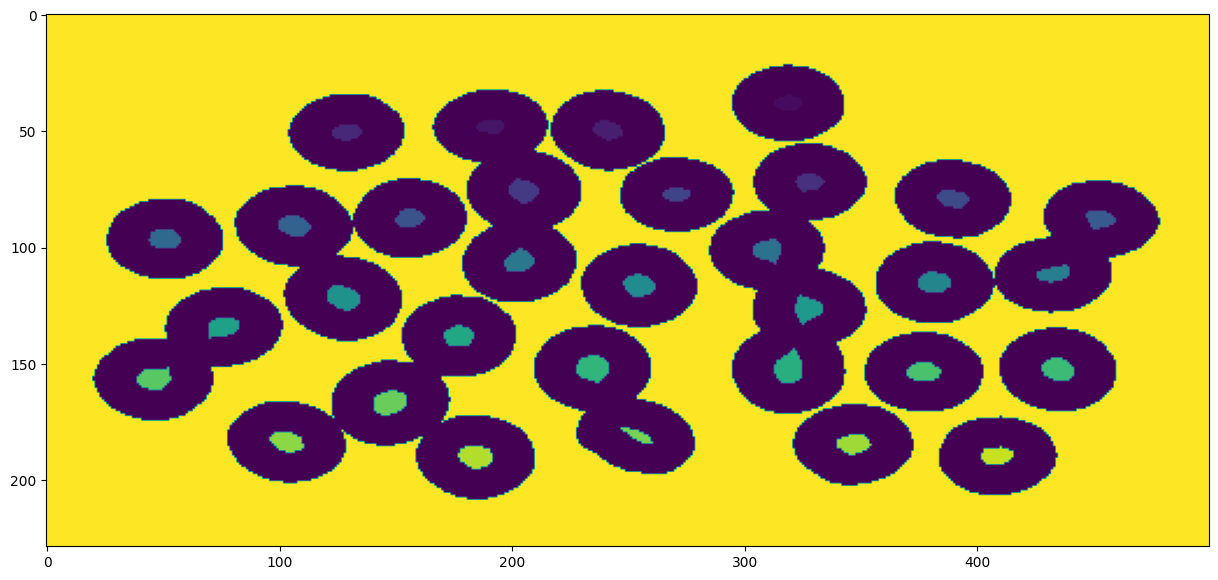

In [ ]:
ret1,thresh_inv = cv2.threshold(smarties,245,1,cv2.THRESH_BINARY)
smarties_marqueur = (num_labels+2)*thresh_inv + labels
plt.figure(figsize=(15,15))
plt.imshow(smarties_marqueur)

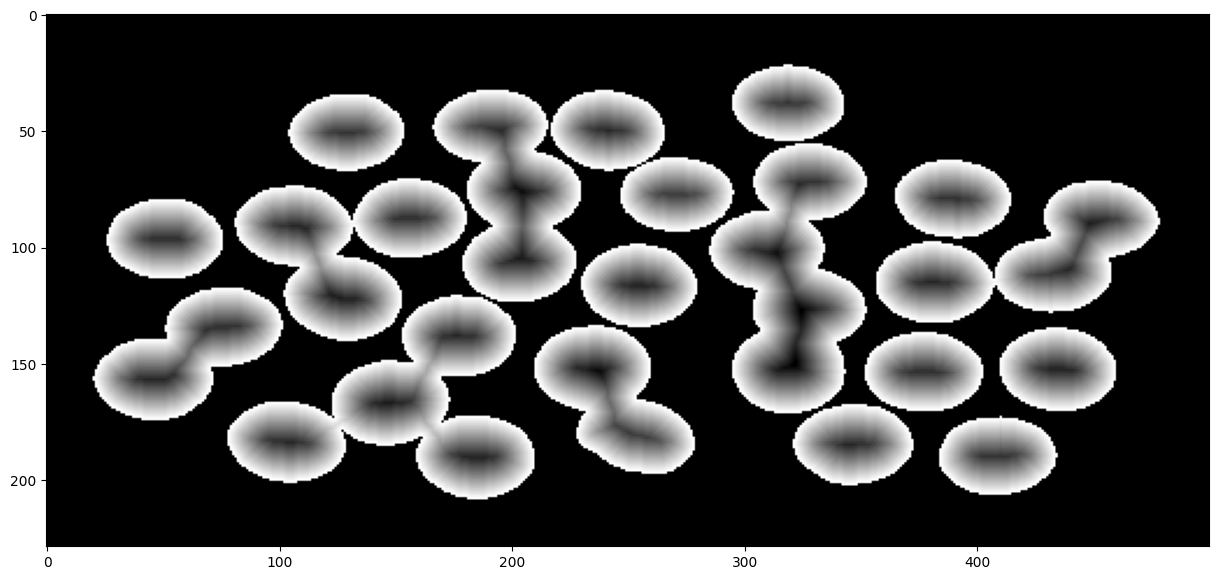

In [ ]:
#marq=abs(255-smartieserode)

#[retmar,marqueurs]= cv2.threshold(marq, 254, 5, cv2.THRESH_BINARY)
smartiesdistance=np.multiply(distb,thresh)
smartiesdistance=np.uint8(smartiesdistance)
plt.figure(figsize=(15,15))
#Carte des distances
plt.imshow(smartiesdistance,'gray')

(229, 500)


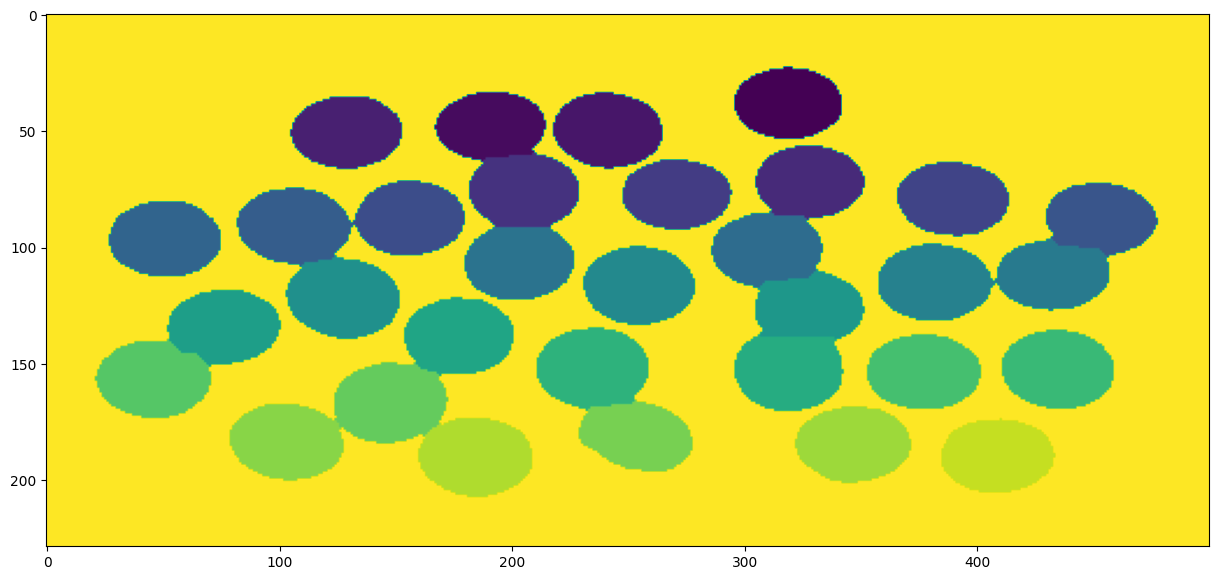

In [ ]:
n=229
p=500

FAH_ligne=[[] for i in range(256)]
FAH_colonne=[[] for i in range(256)]

smarties2 = np.copy(smarties_marqueur)

print(np.shape(smarties_marqueur))
for i in range(np.shape(smarties_marqueur)[0]):
     for j in range(np.shape(smarties_marqueur)[1]):
         if smarties_marqueur[i,j] != 0:
            FAH_ligne[smartiesdistance[i,j]].append(i)
            FAH_colonne[smartiesdistance[i,j]].append(j)




it=0


while it!=256:
    while FAH_ligne[it] !=[]:
        i= FAH_ligne[it].pop(0)
        j= FAH_colonne[it].pop(0)
        
        voisin = [(1,0),(-1,0),(0,1),(0,-1)]
        
        if i == 0: 
            if j == 0:          
                voisin = [(1,0),(0,1)]
            elif j == np.shape(smarties_marqueur)[1] - 1:
                voisin = [(1,0),(0,-1)]
            else:
                voisin = [(1,0),(0,1),(0,-1)]
        elif i == np.shape(smarties_marqueur)[0] - 1:
            if j == 0:          
                voisin = [(-1,0),(0,1)]
            elif j == np.shape(smarties_marqueur)[1] - 1:
                voisin = [(-1,0),(0,-1)]
            else:
                voisin = [(-1,0),(0,1),(0,-1)]
        elif j == 0:
            voisin = [(1,0),(-1,0),(0,1)]
        elif j == np.shape(smarties_marqueur)[1] - 1:
            voisin = [(1,0),(-1,0),(0,-1)]

        for l in range(len(voisin)):
            if smarties2[i+voisin[l][0],j+voisin[l][1]] == 0:
                smarties2[i+voisin[l][0],j+voisin[l][1]] = smarties2[i,j]
                
                FAH_ligne[np.max([smartiesdistance[i+voisin[l][0],j+voisin[l][1]],it])].append(i+voisin[l][0])
                FAH_colonne[np.max([smartiesdistance[i+voisin[l][0],j+voisin[l][1]],it])].append(j+voisin[l][1])

    it+=1
        



plt.figure(figsize=(15,15))
plt.imshow(smarties2)

